D:\Anaconda\lib\site-packages\sklearn\utils\validation.py:70: FutureWarning: Pass classes=[0. 1.], y=[0. 0. 0. ... 0. 0. 0.] as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


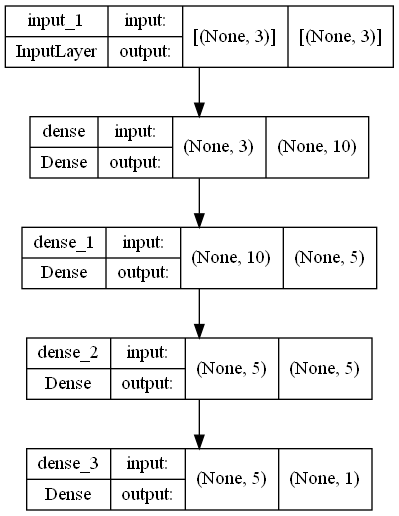

In [1]:
import pandas as pd
import numpy as np
import os
from random import shuffle
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, Input
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import concatenate
from keras.utils.vis_utils import plot_model
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.random
import argparse
import locale
import os

seed = 246

# model-compile parameter sets
model_metrics = 'acc'
epochs = 500
batchs = 64
splits = 0.2
lr        = 3e-4
input_dim = 3
opt = Adam(learning_rate=lr,decay=3e-4/200)

concatenated_df=pd.read_csv("oriI_extraFeatures_Geo.csv")
XY = concatenated_df.values
for i in range(10):
    np.random.shuffle(XY)
X = XY[:,[0,2,3]]
Y = XY[:,[5]]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=splits, random_state=seed)

model = Sequential()
inputShape=(input_dim,)
model.add(Input(shape=inputShape))
x = Dense(10,activation="relu", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(model.output)
x = Dense(5,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
x = Dense(5,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
x = Dense(1,activation ="sigmoid", kernel_initializer="RandomNormal", bias_initializer="RandomNormal")(x)
model = Model(inputs=[model.input],outputs=x)
model.compile(loss="mse",optimizer=opt,metrics=['acc'])

y_train = y_train.flatten()
class_weights = class_weight.compute_class_weight('balanced', np.unique(y_train), y_train)
class_weights = dict(zip(np.unique(y_train),class_weights))

plot_model(model,to_file='FeaturesPlots/model.png',show_shapes=True)

In [2]:
history = model.fit(x=[x_train],y=y_train, validation_data=([x_test], y_test), 
                    epochs=epochs, batch_size=batchs, class_weight=class_weights)

model.save_weights(r'weightANDlearningcurve/GeoIModule_model.h5')
eval_model=[]
eval_model.append(model.evaluate([x_test], y_test)[1])
print("\nTest Accuracy: %.4f" % eval_model[0])

Epoch 1/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.1616 - acc: 0.6652 - val_loss: 0.1059 - val_acc: 0.8587
Epoch 2/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.1017 - acc: 0.8478 - val_loss: 0.1131 - val_acc: 0.8515
Epoch 3/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0970 - acc: 0.8542 - val_loss: 0.1058 - val_acc: 0.8566
Epoch 4/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0966 - acc: 0.8522 - val_loss: 0.0984 - val_acc: 0.8632
Epoch 5/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0965 - acc: 0.8513 - val_loss: 0.1077 - val_acc: 0.8528
Epoch 6/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0964 - acc: 0.8504 - val_loss: 0.0999 - val_acc: 0.8615
Epoch 7/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0964 - acc: 0.8504 - val_loss: 0.1158 - val_acc: 0.8412
Epoch 8/500
10500/10500 [=========

Epoch 60/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8506 - val_loss: 0.1071 - val_acc: 0.8527
Epoch 61/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8507 - val_loss: 0.1070 - val_acc: 0.8527
Epoch 62/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8506 - val_loss: 0.1083 - val_acc: 0.8475
Epoch 63/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8507 - val_loss: 0.1105 - val_acc: 0.8460
Epoch 64/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8508 - val_loss: 0.1069 - val_acc: 0.8525
Epoch 65/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8508 - val_loss: 0.1025 - val_acc: 0.8560
Epoch 66/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0958 - acc: 0.8507 - val_loss: 0.1073 - val_acc: 0.8491
Epoch 67/500
10500/10500 [=

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8507 - val_loss: 0.1083 - val_acc: 0.8476
Epoch 119/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8505 - val_loss: 0.1099 - val_acc: 0.8460
Epoch 120/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8508 - val_loss: 0.1137 - val_acc: 0.8425
Epoch 121/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8506 - val_loss: 0.1080 - val_acc: 0.8476
Epoch 122/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8506 - val_loss: 0.1070 - val_acc: 0.8524
Epoch 123/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8508 - val_loss: 0.1086 - val_acc: 0.8474
Epoch 124/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0957 - acc: 0.8508 - val_loss: 0.1033 - val_acc: 0.8553
Epoch 125/500
10500/10500 [=======

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8504 - val_loss: 0.1095 - val_acc: 0.8462
Epoch 177/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8504 - val_loss: 0.1080 - val_acc: 0.8480
Epoch 178/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8502 - val_loss: 0.1113 - val_acc: 0.8446
Epoch 179/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8498 - val_loss: 0.1016 - val_acc: 0.8569
Epoch 180/500
10500/10500 [==============================] - 10s 950us/step - loss: 0.0956 - acc: 0.8506 - val_loss: 0.1122 - val_acc: 0.8430
Epoch 181/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8501 - val_loss: 0.1072 - val_acc: 0.8481
Epoch 182/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0956 - acc: 0.8503 - val_loss: 0.1056 - val_acc: 0.8496
Epoch 183/500
10500/10500 [=====

10500/10500 [==============================] - 10s 998us/step - loss: 0.0873 - acc: 0.8630 - val_loss: 0.0944 - val_acc: 0.8648
Epoch 235/500
10500/10500 [==============================] - 10s 987us/step - loss: 0.0872 - acc: 0.8631 - val_loss: 0.0994 - val_acc: 0.8600
Epoch 236/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0872 - acc: 0.8632 - val_loss: 0.1006 - val_acc: 0.8575
Epoch 237/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0872 - acc: 0.8630 - val_loss: 0.1002 - val_acc: 0.8579
Epoch 238/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0872 - acc: 0.8630 - val_loss: 0.0943 - val_acc: 0.8647
Epoch 239/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0872 - acc: 0.8635 - val_loss: 0.1003 - val_acc: 0.8582
Epoch 240/500
10500/10500 [==============================] - 10s 966us/step - loss: 0.0872 - acc: 0.8633 - val_loss: 0.0975 - val_acc: 0.8620
Epoch 241/500
10500/10500 [=

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8650 - val_loss: 0.1003 - val_acc: 0.8604
Epoch 293/500
10500/10500 [==============================] - 10s 976us/step - loss: 0.0867 - acc: 0.8647 - val_loss: 0.0950 - val_acc: 0.8661
Epoch 294/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8650 - val_loss: 0.0969 - val_acc: 0.8636
Epoch 295/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8646 - val_loss: 0.0933 - val_acc: 0.8676
Epoch 296/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8651 - val_loss: 0.0983 - val_acc: 0.8625
Epoch 297/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8648 - val_loss: 0.0967 - val_acc: 0.8654
Epoch 298/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0867 - acc: 0.8650 - val_loss: 0.0984 - val_acc: 0.8623
Epoch 299/500
10500/10500 [=====

10500/10500 [==============================] - 11s 1ms/step - loss: 0.0863 - acc: 0.8655 - val_loss: 0.0964 - val_acc: 0.8648
Epoch 351/500
10500/10500 [==============================] - 10s 979us/step - loss: 0.0863 - acc: 0.8658 - val_loss: 0.0986 - val_acc: 0.8634
Epoch 352/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0863 - acc: 0.8656 - val_loss: 0.0962 - val_acc: 0.8642
Epoch 353/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0863 - acc: 0.8659 - val_loss: 0.0972 - val_acc: 0.8635
Epoch 354/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0863 - acc: 0.8656 - val_loss: 0.0977 - val_acc: 0.8634
Epoch 355/500
10500/10500 [==============================] - 10s 987us/step - loss: 0.0863 - acc: 0.8656 - val_loss: 0.0956 - val_acc: 0.8658
Epoch 356/500
10500/10500 [==============================] - 10s 911us/step - loss: 0.0863 - acc: 0.8657 - val_loss: 0.0953 - val_acc: 0.8683
Epoch 357/500
10500/10500 [=

10500/10500 [==============================] - 9s 902us/step - loss: 0.0858 - acc: 0.8660 - val_loss: 0.0966 - val_acc: 0.8653
Epoch 409/500
10500/10500 [==============================] - 10s 943us/step - loss: 0.0858 - acc: 0.8661 - val_loss: 0.0978 - val_acc: 0.8643
Epoch 410/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0858 - acc: 0.8660 - val_loss: 0.0973 - val_acc: 0.8643
Epoch 411/500
10500/10500 [==============================] - 10s 962us/step - loss: 0.0858 - acc: 0.8660 - val_loss: 0.0966 - val_acc: 0.8648
Epoch 412/500
10500/10500 [==============================] - 10s 944us/step - loss: 0.0858 - acc: 0.8660 - val_loss: 0.0960 - val_acc: 0.8659
Epoch 413/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0858 - acc: 0.8661 - val_loss: 0.0951 - val_acc: 0.8660
Epoch 414/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0858 - acc: 0.8662 - val_loss: 0.0995 - val_acc: 0.8613
Epoch 415/500
10500/10500 [

10500/10500 [==============================] - 10s 923us/step - loss: 0.0854 - acc: 0.8668 - val_loss: 0.0943 - val_acc: 0.8685
Epoch 467/500
10500/10500 [==============================] - 10s 910us/step - loss: 0.0854 - acc: 0.8669 - val_loss: 0.0951 - val_acc: 0.8680
Epoch 468/500
10500/10500 [==============================] - 10s 998us/step - loss: 0.0854 - acc: 0.8670 - val_loss: 0.0957 - val_acc: 0.8653
Epoch 469/500
10500/10500 [==============================] - 10s 944us/step - loss: 0.0854 - acc: 0.8670 - val_loss: 0.0974 - val_acc: 0.8635
Epoch 470/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0854 - acc: 0.8667 - val_loss: 0.0944 - val_acc: 0.8682
Epoch 471/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0854 - acc: 0.8670 - val_loss: 0.0961 - val_acc: 0.8645
Epoch 472/500
10500/10500 [==============================] - 11s 1ms/step - loss: 0.0854 - acc: 0.8668 - val_loss: 0.0956 - val_acc: 0.8653
Epoch 473/500
10500/10500 

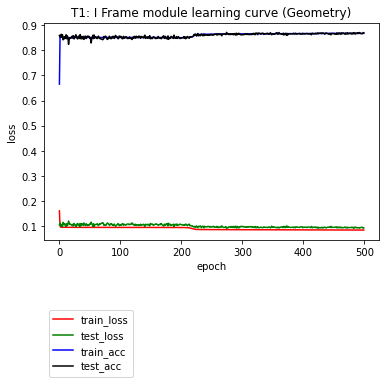

In [3]:
plt.plot(history.history['loss'],color='r')
plt.plot(history.history['val_loss'],color='g')
plt.plot(history.history['acc'],color='b')
plt.plot(history.history['val_acc'],color='k')
plt.title('T1: I Frame module learning curve (Geometry)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'test_loss','train_acc', 'test_acc'], loc='upper left',bbox_to_anchor=(0,-0.3))
plt.savefig('FeaturesPlots/I_GeoTrainingCurve.jpg', bbox_inches='tight', dpi=1280)
plt.show()

import pickle
with open('weightANDlearningcurve/GeoIModule_history.txt', 'wb') as file_txt:
    pickle.dump(history.history, file_txt)

In [4]:
np.set_printoptions(suppress=True)

g_weight1=model.get_weights()[0]
g_bias1=model.get_weights()[1]
g_weight2=model.get_weights()[2]
g_bias2=model.get_weights()[3]
g_weight3=model.get_weights()[4]
g_bias3=model.get_weights()[5]


print("\ng_weight1: ")
for a in g_weight1:
    for b in a:
        print(b,end=",")
        
print("\n\ng_bias1: ")
for a in g_bias1:
        print(a,end=",")
        
print("\n\ng_weight2: ")
for a in g_weight2:
    for b in a:
        print(b,end=",")
        
print("\n\ng_bias2: ")
for a in g_bias2:
        print(a,end=",")

print("\n\na_weight3: ")
for a in g_weight3:
    for b in a:
        print(b,end=",")
        
print("\n\na_bias3: ")
for a in g_bias3:
        print(a,end=",")
        
# a_weight1=model.get_layer(index=0).get_weights()
# a_weight2=model.get_layer(index=1).get_weights()
        
# print(a_weight1)
# print(a_weight2)


g_weight1: 
-0.0324416,-0.41121468,1.8345684,-0.015316221,1.3752792,0.42480928,-0.44082147,0.0737849,-0.033243075,0.009416436,-0.05279243,0.18880378,0.21160956,-0.015661037,0.10543052,0.4558831,0.50894874,-0.05796933,0.73552275,0.02260671,0.023660664,1.1593318,0.3736321,0.011745878,0.42782724,0.48186556,1.1627843,-0.02295733,0.73201203,-0.058247216,

g_bias1: 
-0.03996204,-0.03233585,-0.042905282,-0.008310803,-0.041545264,-0.15518871,-0.006443896,-0.06701738,-0.23993658,-0.011078929,

g_weight2: 
0.08180126,-0.02657902,0.04832731,0.04043187,-0.014197372,-2.301331,-0.13933927,-0.3514479,0.31587556,-2.329453,0.69075245,1.0233116,2.4781904,-0.8485307,-0.25756204,-0.09886902,-0.0026422527,0.024132797,0.044344135,0.007887819,0.47288868,0.87951744,1.957888,-0.5228458,-0.4287644,-0.12995662,0.42009354,0.8369945,-0.495393,-0.8555776,-2.5648782,-0.18122083,-0.44022456,0.10932147,-2.2325065,-0.023971366,0.038233325,-0.051773895,-0.067025565,0.0058269748,-0.8926927,0.30022377,-0.11750651,-0.4860